# 06b — Failure Case Analysis (from raw .tif)

**Mục đích:** So sánh với `06_failure_case_analysis.ipynb` (dùng cache HDF5).  
Notebook này load trực tiếp ảnh `.tif` gốc để cung cấp dữ liệu pixel `(13, H, W)` cho tất cả các bộ phát hiện nguyên nhân lỗi.

### Điểm khác biệt chính

| | NB 06 (cache HDF5) | NB 06b (raw .tif) |
|---|---|---|
| Cloud Cover detector | Thiếu pixel → bỏ qua | Đọc B09, B10 trực tiếp |
| Mixed Scene detector | Dùng embedding cosine (kém nhạy) | Dùng spatial CV từ pixel |
| Rare Class detector |  Hoạt động bình thường | Giống nhau |
| Seasonal Variation | Hoạt động bình thường | Giống nhau |
| Gallery visualization | Có thể thiếu ảnh | Luôn có ảnh RGB |

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

#print(f"Project root: {PROJECT_ROOT}")

In [2]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.size'] = 11

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

from collections import Counter
import rasterio

print(f"PyTorch {torch.__version__}")
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {DEVICE}")

PyTorch 2.0.1
Device: mps


## 1. Load HDF5 Embeddings + Dataset paths

In [3]:
import h5py

H5_PATH = PROJECT_ROOT / "results" / "band_embeddings.h5"

with h5py.File(H5_PATH, "r") as f:
    print("=== HDF5 Contents ===")
    for key in f.keys():
        print(f"  {key}: shape={f[key].shape}, dtype={f[key].dtype}")
    
    embeddings = torch.from_numpy(f["embeddings"][:])  # (N, 13, 512)
    labels_int = torch.from_numpy(f["labels"][:])       # (N,)
    label_names_raw = f["label_names"][:]                # (N,)
    paths_raw = f["paths"][:]                             # (N,)

label_names = [
    s.decode("utf-8") if isinstance(s, bytes) else str(s)
    for s in label_names_raw
]
image_paths = [
    s.decode("utf-8") if isinstance(s, bytes) else str(s)
    for s in paths_raw
]

# === Remap paths: HDF5 was created on Colab with prefix /content/drive/MyDrive/ACIVS_ThayBach/ ===
# Detect and replace the Colab prefix with the local PROJECT_ROOT
COLAB_PREFIX = "/content/drive/MyDrive/ACIVS_ThayBach/"

def remap_path(p):
    if p.startswith(COLAB_PREFIX):
        return str(PROJECT_ROOT / p[len(COLAB_PREFIX):])
    return p

image_paths = [remap_path(p) for p in image_paths]
print(f"\nPath remapping applied (Colab → local).")
#print(f"Sample path: {image_paths[0]}")

N_total = embeddings.shape[0]
print(f"\nLoaded {N_total} samples, shape={embeddings.shape}")
print(f"Unique classes: {sorted(set(label_names))}")
print(f"Class distribution: {Counter(label_names)}")

# Verify paths exist
n_exist = sum(1 for p in image_paths if Path(p).exists())
print(f"\nImages found on disk: {n_exist}/{N_total}")
if n_exist == 0:
    print("WARNING: No .tif files found. Check your data/EuroSAT_MS path.")
else:
    print(f"SUCCESS: {n_exist}/{N_total} images found after path remapping!")

=== HDF5 Contents ===
  embeddings: shape=(21600, 13, 512), dtype=float32
  label_names: shape=(21600,), dtype=object
  labels: shape=(21600,), dtype=int64
  paths: shape=(21600,), dtype=object

Path remapping applied (Colab → local).

Loaded 21600 samples, shape=torch.Size([21600, 13, 512])
Unique classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Class distribution: Counter({'AnnualCrop': 2400, 'HerbaceousVegetation': 2400, 'Residential': 2400, 'SeaLake': 2400, 'Forest': 2400, 'River': 2000, 'Highway': 2000, 'Industrial': 2000, 'PermanentCrop': 2000, 'Pasture': 1600})

Images found on disk: 21600/21600
SUCCESS: 21600/21600 images found after path remapping!


## 2. Prepare Query / Gallery Split (same as NB 06)

In [4]:
unique_classes = sorted(set(label_names))
class_to_idx = {c: i for i, c in enumerate(unique_classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

labels_consistent = torch.tensor([class_to_idx[ln] for ln in label_names])

# Stratified split: 20% query, 80% gallery (same seed as NB 06)
np.random.seed(42)
query_indices = []
gallery_indices = []

for cls in unique_classes:
    cls_indices = [i for i, ln in enumerate(label_names) if ln == cls]
    np.random.shuffle(cls_indices)
    n_query = max(1, int(len(cls_indices) * 0.2))
    query_indices.extend(cls_indices[:n_query])
    gallery_indices.extend(cls_indices[n_query:])

query_indices = sorted(query_indices)
gallery_indices = sorted(gallery_indices)

print(f"Query set:   {len(query_indices)} samples")
print(f"Gallery set: {len(gallery_indices)} samples")
print(f"Query class dist: {Counter(label_names[i] for i in query_indices)}")

Query set:   4320 samples
Gallery set: 17280 samples
Query class dist: Counter({'Forest': 480, 'Residential': 480, 'SeaLake': 480, 'HerbaceousVegetation': 480, 'AnnualCrop': 480, 'Highway': 400, 'River': 400, 'PermanentCrop': 400, 'Industrial': 400, 'Pasture': 320})


## 3. Compute Fused Embeddings (same pipeline as NB 06)

In [5]:
from src.models.retrieval_pipeline import MultispectralRetrievalPipeline

pipeline = MultispectralRetrievalPipeline(
    sigma=0.5, num_steps=5, lr=0.01, lambda_m=0.1, k=5,
)

# Per-class query embeddings using CLIP text encoder
# Per Design Authority (PROJECT_CONTEXT.md Section 0, Rule 1):
# query_embedding MUST be the CLIP text embedding of the class.
from src.utils.shared import load_openai_clip_model
from src.datasets.eurosat import CLASS_TEXT_MAP
from src.experiments.eurosat_5fold_cv import encode_class_text_features

_ckpt = PROJECT_ROOT / 'checkpoints' / 'ViT-B-16.pt'
_device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
_clip_model, _clip_tokenize = load_openai_clip_model(_ckpt, _device)

_class_prompts = [
    f"A satellite image of {CLASS_TEXT_MAP.get(cls, cls)}."
    for cls in unique_classes
]
_text_features = encode_class_text_features(
    _clip_model, _clip_tokenize,
    class_prompts=_class_prompts,
    device=_device,
)

class_query_embeddings = {}
for idx, cls in enumerate(unique_classes):
    class_query_embeddings[cls] = _text_features[idx]

print(f"Built CLIP text query embeddings for {len(class_query_embeddings)} classes")
for cls in unique_classes:
    print(f"  {cls}: norm={class_query_embeddings[cls].norm():.4f}")


Built CLIP text query embeddings for 10 classes
  AnnualCrop: norm=1.0000
  Forest: norm=1.0000
  HerbaceousVegetation: norm=1.0000
  Highway: norm=1.0000
  Industrial: norm=1.0000
  Pasture: norm=1.0000
  PermanentCrop: norm=1.0000
  Residential: norm=1.0000
  River: norm=1.0000
  SeaLake: norm=1.0000


In [6]:
%%time

# Fuse query set
query_fused = []
for idx in query_indices:
    cls = label_names[idx]
    result = pipeline.retrieve(
        band_embeddings=embeddings[idx],
        query_embedding=class_query_embeddings[cls],
    )
    query_fused.append(result.fused_embedding)

query_features = torch.stack(query_fused)
query_labels_int = labels_consistent[query_indices]
query_label_names = [label_names[i] for i in query_indices]

# Fuse gallery set
gallery_fused = []
for idx in gallery_indices:
    cls = label_names[idx]
    result = pipeline.retrieve(
        band_embeddings=embeddings[idx],
        query_embedding=class_query_embeddings[cls],
    )
    gallery_fused.append(result.fused_embedding)

gallery_features = torch.stack(gallery_fused)
gallery_labels_int = labels_consistent[gallery_indices]

print(f"Query features:   {query_features.shape}")
print(f"Gallery features: {gallery_features.shape}")

Query features:   torch.Size([4320, 512])
Gallery features: torch.Size([17280, 512])
CPU times: user 27.1 s, sys: 17.9 s, total: 44.9 s
Wall time: 32.6 s


## 4. Identify Failures (R@1 miss)

In [7]:
from src.utils.failure_analysis import (
    identify_failure_cases,
    classify_failure_causes,
    compute_failure_statistics,
    compute_class_embedding_stats,
    print_failure_summary,
    plot_failure_cause_distribution,
    plot_failure_gallery,
    plot_confusion_heatmap,
    FAILURE_CAUSES, FAILURE_CAUSE_LABELS,
)

failures, summary = identify_failure_cases(
    query_features=query_features,
    query_labels=query_labels_int,
    gallery_features=gallery_features,
    gallery_labels=gallery_labels_int,
    label_names=query_label_names,
    idx_to_class=idx_to_class,
    threshold_rank=1,
    image_paths=[image_paths[i] for i in query_indices],
)

print(f"=== Retrieval Summary ===")
print(f"Total queries:  {summary['total_queries']}")
print(f"R@1 hits:       {summary['total_hits']} ({summary['hit_rate']*100:.1f}%)")
print(f"R@1 failures:   {summary['total_failures']} ({summary['failure_rate']*100:.1f}%)")

=== Retrieval Summary ===
Total queries:  4320
R@1 hits:       3779 (87.5%)
R@1 failures:   541 (12.5%)


## 5. Load raw .tif images for ALL failure cases

**Đây là điểm khác biệt chính:** mỗi failure case sẽ có dữ liệu pixel thật `(13, H, W)` để các detector Cloud Cover và Mixed Scene hoạt động đúng.

In [8]:
def load_tif_image(path: str, reflectance_scale: float = 10000.0) -> torch.Tensor:
    """Load a 13-band .tif file and return (13, H, W) tensor in [0, 1]."""
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)  # (13, H, W)
    img = img / reflectance_scale
    img = np.clip(img, 0.0, 1.0)
    return torch.from_numpy(img)


# Load images for all failure cases
failure_images = []
failure_band_embs = []
images_loaded = 0
images_failed = 0

for fc in failures:
    # Band embeddings (from HDF5)
    orig_idx = query_indices[fc.sample_index]
    failure_band_embs.append(embeddings[orig_idx])  # (13, 512)
    
    # Raw .tif image
    img_path = fc.image_path
    if img_path and Path(img_path).exists():
        try:
            img = load_tif_image(img_path)
            failure_images.append(img)
            images_loaded += 1
        except Exception as e:
            print(f"  ERROR loading {img_path}: {e}")
            failure_images.append(None)
            images_failed += 1
    else:
        failure_images.append(None)
        images_failed += 1

print(f"\n=== Image Loading Summary ===")
print(f"  Loaded successfully: {images_loaded}/{len(failures)}")
print(f"  Failed/missing:     {images_failed}/{len(failures)}")

# Show sample pixel statistics for loaded images
if images_loaded > 0:
    sample_img = next(img for img in failure_images if img is not None)
    print(f"\n  Sample image shape: {sample_img.shape}")
    print(f"  B09 (WV) mean:  {sample_img[9].mean():.4f}")
    print(f"  B10 (Cirrus) mean: {sample_img[10].mean():.4f}")
    print(f"  Overall min/max: [{sample_img.min():.4f}, {sample_img.max():.4f}]")


=== Image Loading Summary ===
  Loaded successfully: 541/541
  Failed/missing:     0/541

  Sample image shape: torch.Size([13, 64, 64])
  B09 (WV) mean:  0.0014
  B10 (Cirrus) mean: 0.2649
  Overall min/max: [0.0010, 0.5012]


## 6. Classify Failure Causes (with raw pixel data)
- **Cloud Cover:** kiểm tra B09 > 0.25 hoặc B10 > 0.15 → phát hiện mây/cirrus
- **Mixed Scene:** tính coefficient of variation spatial → phát hiện cảnh hỗn hợp
- **Rare Class & Seasonal:** hoạt động giống NB 06

In [9]:
# Compute class centroids and stds for seasonal variation detection
centroids, stds = compute_class_embedding_stats(embeddings, label_names)

# Gallery class distribution
gallery_class_dist = Counter(label_names[i] for i in gallery_indices)
print("Gallery class distribution:")
for cls in sorted(gallery_class_dist.keys()):
    print(f"  {cls}: {gallery_class_dist[cls]}")

# Show detection inputs for a few failures
print("\n=== Pre-classification diagnostics (first 5 failures) ===")
for i, fc in enumerate(failures[:5]):
    img = failure_images[i]
    emb = failure_band_embs[i]
    cls = fc.true_label
    
    print(f"\n  [{i}] True={cls}, Pred={fc.predicted_label}")
    if img is not None:
        b09 = img[9].mean().item()
        b10 = img[10].mean().item()
        band_means = img.mean(dim=(1, 2))
        band_stds = img.std(dim=(1, 2))
        cv = (band_stds / (band_means + 1e-8)).mean().item()
        print(f"    B09(WV)={b09:.4f} (thr=0.25), B10(Cirrus)={b10:.4f} (thr=0.15)")
        print(f"    Spatial CV={cv:.4f} (thr=0.70)")
    else:
        print(f"    No image available")
    
    if cls in centroids:
        sample_mean = emb.mean(dim=0)
        dist = torch.norm(sample_mean - centroids[cls]).item()
        zscore = dist / max(stds[cls], 1e-8)
        print(f"    Centroid dist={dist:.4f}, z-score={zscore:.2f} (thr=1.5)")

Gallery class distribution:
  AnnualCrop: 1920
  Forest: 1920
  HerbaceousVegetation: 1920
  Highway: 1600
  Industrial: 1600
  Pasture: 1280
  PermanentCrop: 1600
  Residential: 1920
  River: 1600
  SeaLake: 1920

=== Pre-classification diagnostics (first 5 failures) ===

  [0] True=Highway, Pred=AnnualCrop
    B09(WV)=0.0014 (thr=0.25), B10(Cirrus)=0.2649 (thr=0.15)
    Spatial CV=0.2758 (thr=0.70)
    Centroid dist=0.1413, z-score=5.32 (thr=1.5)

  [1] True=Pasture, Pred=River
    B09(WV)=0.0016 (thr=0.25), B10(Cirrus)=0.2059 (thr=0.15)
    Spatial CV=0.2126 (thr=0.70)
    Centroid dist=0.1483, z-score=7.06 (thr=1.5)

  [2] True=Forest, Pred=HerbaceousVegetation
    B09(WV)=0.0015 (thr=0.25), B10(Cirrus)=0.1315 (thr=0.15)
    Spatial CV=0.1144 (thr=0.70)
    Centroid dist=0.0911, z-score=4.32 (thr=1.5)

  [3] True=Residential, Pred=Highway
    B09(WV)=0.0010 (thr=0.25), B10(Cirrus)=0.1680 (thr=0.15)
    Spatial CV=0.1922 (thr=0.70)
    Centroid dist=0.1487, z-score=5.46 (thr=1.5)

 

In [10]:
# Classify with REAL PIXEL DATA
failures = classify_failure_causes(
    failures,
    images=failure_images,           # ← Raw .tif pixel data!
    band_embeddings=failure_band_embs,
    class_distribution=dict(gallery_class_dist),
    class_centroids=centroids,
    class_stds=stds,
    # Thresholds (same defaults)
    cirrus_threshold=0.15,
    wv_threshold=0.25,
    entropy_threshold=0.7,
    rare_percentile=20.0,
    deviation_threshold=1.5,
)

# Report cause distribution
cause_counts = Counter(fc.failure_cause for fc in failures)
print("=" * 60)
print("  FAILURE CAUSE BREAKDOWN (raw .tif version)")
print("=" * 60)
for cause in FAILURE_CAUSES:
    count = cause_counts.get(cause, 0)
    pct = count / max(len(failures), 1) * 100
    label = FAILURE_CAUSE_LABELS[cause]
    print(f"  {label:20s}: {count:4d} ({pct:5.1f}%)")
print(f"  {'TOTAL':20s}: {len(failures):4d}")

  FAILURE CAUSE BREAKDOWN (raw .tif version)
  Cloud Cover         :   90 ( 16.6%)
  Mixed Scene         :    0 (  0.0%)
  Rare Class          :    0 (  0.0%)
  Seasonal Variation  :  451 ( 83.4%)
  TOTAL               :  541


## 7. Compute Band Attributions for Failure Cases

In [11]:
from src.models.band_attribution import compute_band_attribution

failure_attributions = []
for i, fc in enumerate(failures):
    cls = fc.true_label
    query_emb = class_query_embeddings.get(cls, None)
    band_emb = failure_band_embs[i]
    
    if query_emb is not None:
        attr = compute_band_attribution(
            band_embeddings=band_emb,
            query_embedding=query_emb,
            sigma=0.5,
        )
        failure_attributions.append(attr.normalized_attribution.numpy())
        fc.band_attribution = attr.normalized_attribution.numpy()
    else:
        failure_attributions.append(None)

print(f"Computed attributions for {sum(1 for a in failure_attributions if a is not None)}/{len(failures)} failures")

Computed attributions for 541/541 failures


## 8. Full Statistics & Summary

In [12]:
result = compute_failure_statistics(
    failures,
    class_names=unique_classes,
    total_samples=len(query_indices),
)

report_text = print_failure_summary(result)

  FAILURE CASE ANALYSIS SUMMARY

  Total queries:   4320
  Total failures:  541
  Failure rate:    12.5%
  Threshold:       R@1 miss

------------------------------------------------------------------------
  FAILURE CAUSE BREAKDOWN
------------------------------------------------------------------------
  Cloud Cover             90  ( 16.6%)  Classes: AnnualCrop, HerbaceousVegetation, Highway, Industrial, PermanentCrop, ...
  Mixed Scene              0  (  0.0%)  Classes: 
  Rare Class               0  (  0.0%)  Classes: 
  Seasonal Variation     451  ( 83.4%)  Classes: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, ...

------------------------------------------------------------------------
  PER-CLASS FAILURE DETAILS
------------------------------------------------------------------------

  ▸ AnnualCrop
    Failures: 63, Avg rank: 8.3, Mean AP: 0.299
    Confused with: PermanentCrop(25), Highway(15), Pasture(9)
    Causes: Cloud Cover:10, Seasonal Variation:53

  ▸

## 9. Visualization: Failure Cause Distribution

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_tif/failure_cause_distribution.png


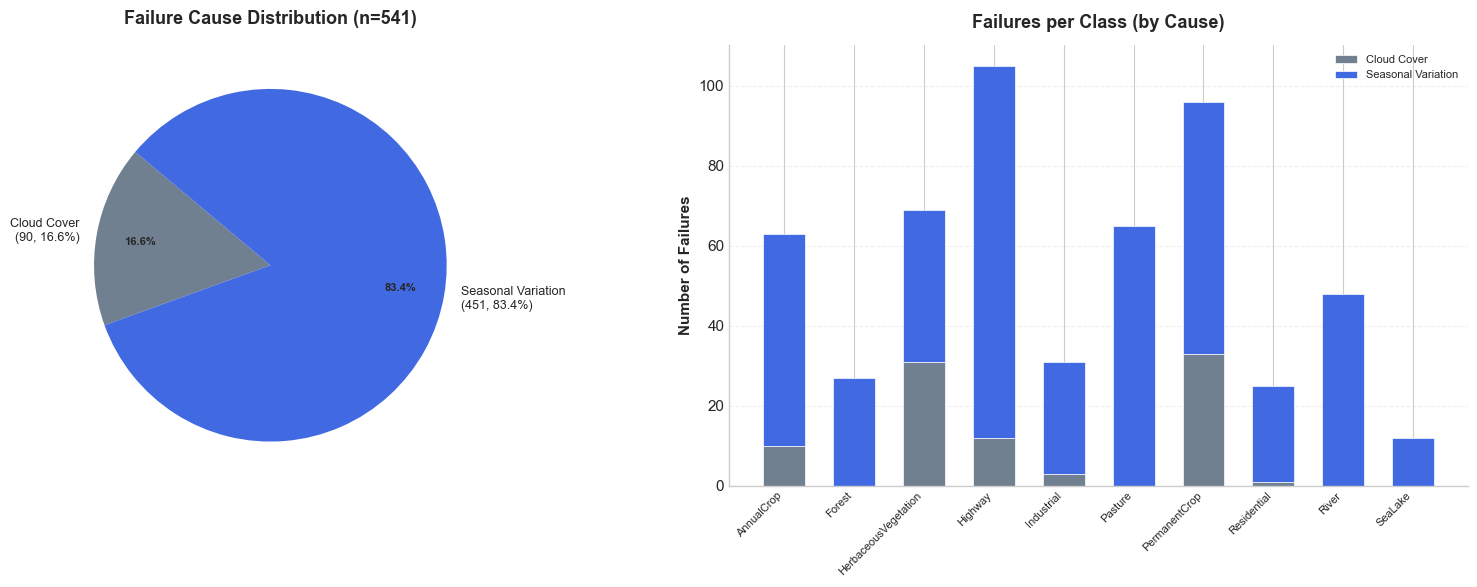

In [13]:
save_dir = PROJECT_ROOT / "results" / "failure_analysis_tif"
save_dir.mkdir(parents=True, exist_ok=True)

fig_dist, _ = plot_failure_cause_distribution(
    result,
    figsize=(16, 6),
    save_path=str(save_dir / "failure_cause_distribution.png"),
)
plt.show()

## 10. Visualization: Failure Gallery (RGB + Attribution + Details)

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_tif/failure_gallery.png


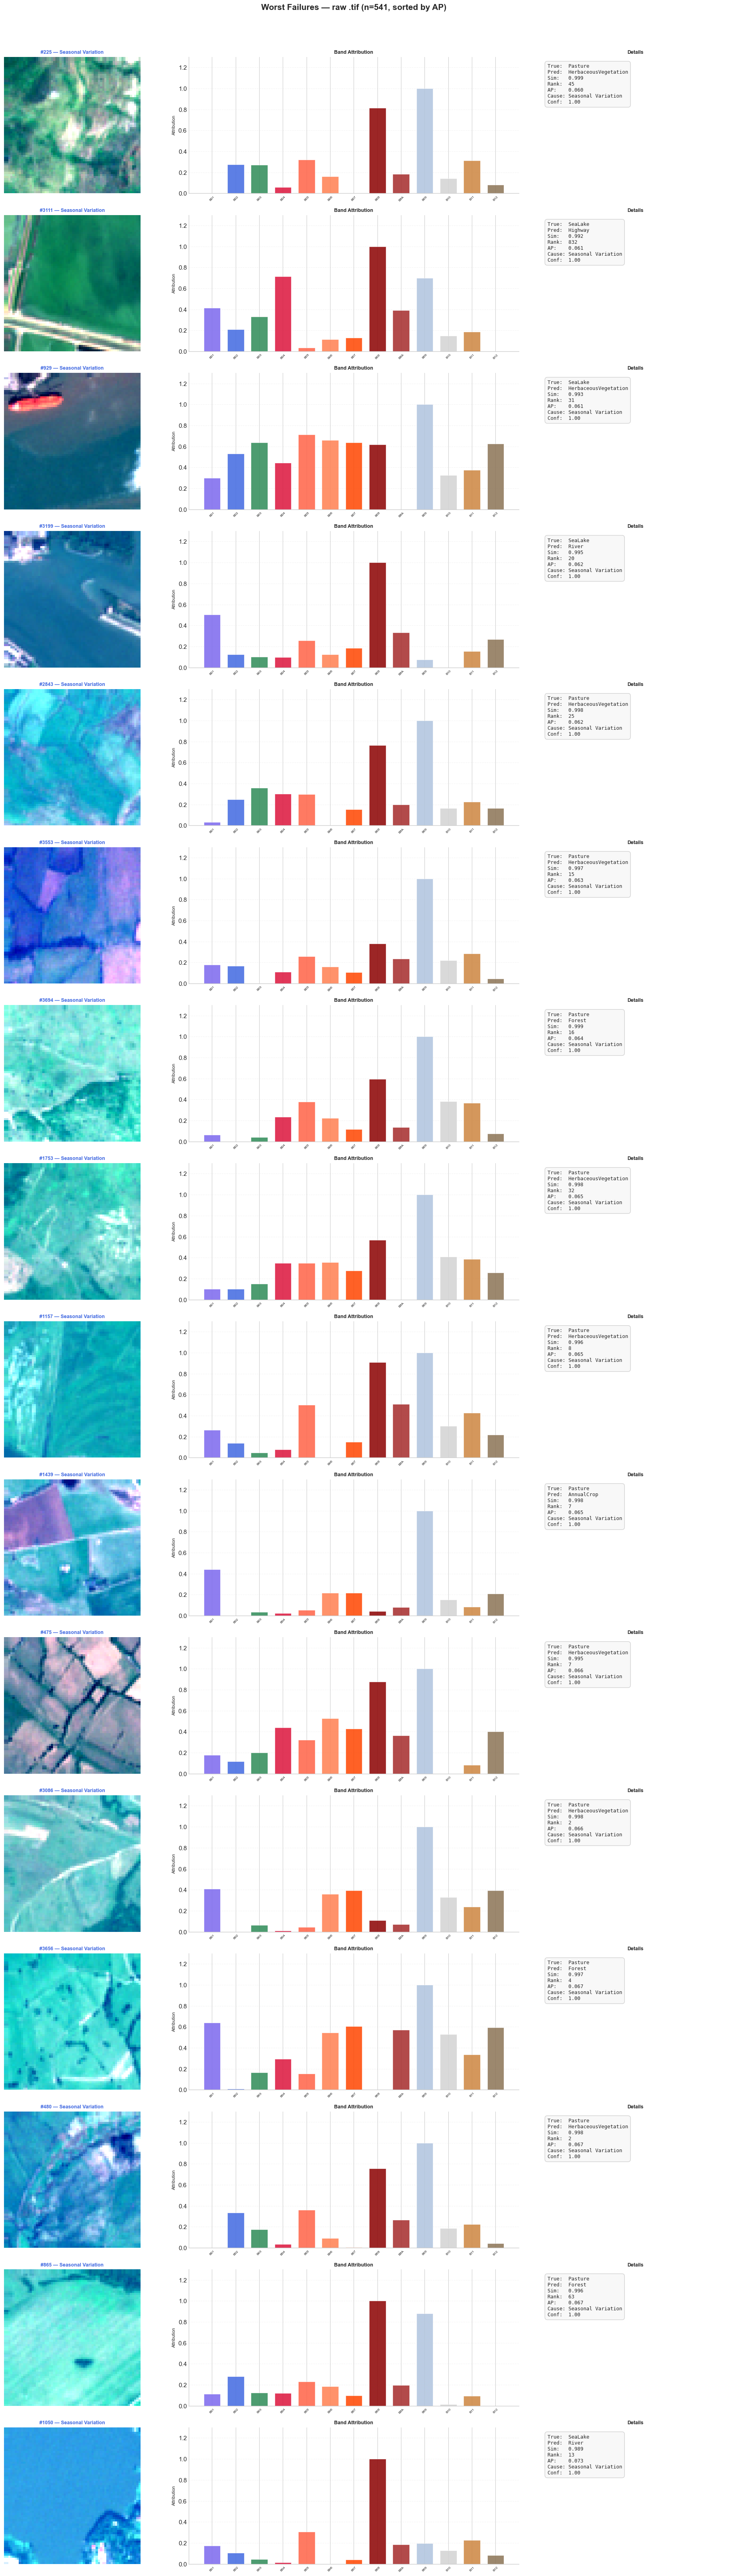

In [14]:
# Sort by AP (worst first)
sorted_indices = sorted(range(len(failures)), key=lambda i: failures[i].average_precision)
sorted_failures = [failures[i] for i in sorted_indices]
sorted_images = [failure_images[i] for i in sorted_indices]
sorted_attrs = [failure_attributions[i] for i in sorted_indices]

fig_gallery, _ = plot_failure_gallery(
    sorted_failures,
    images=sorted_images,
    band_attributions=sorted_attrs,
    n_show=min(16, len(sorted_failures)),
    save_path=str(save_dir / "failure_gallery.png"),
    suptitle=f"Worst Failures — raw .tif (n={len(failures)}, sorted by AP)",
)
plt.show()

## 11. Visualization: Confusion Matrix

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_tif/failure_confusion_matrix.png


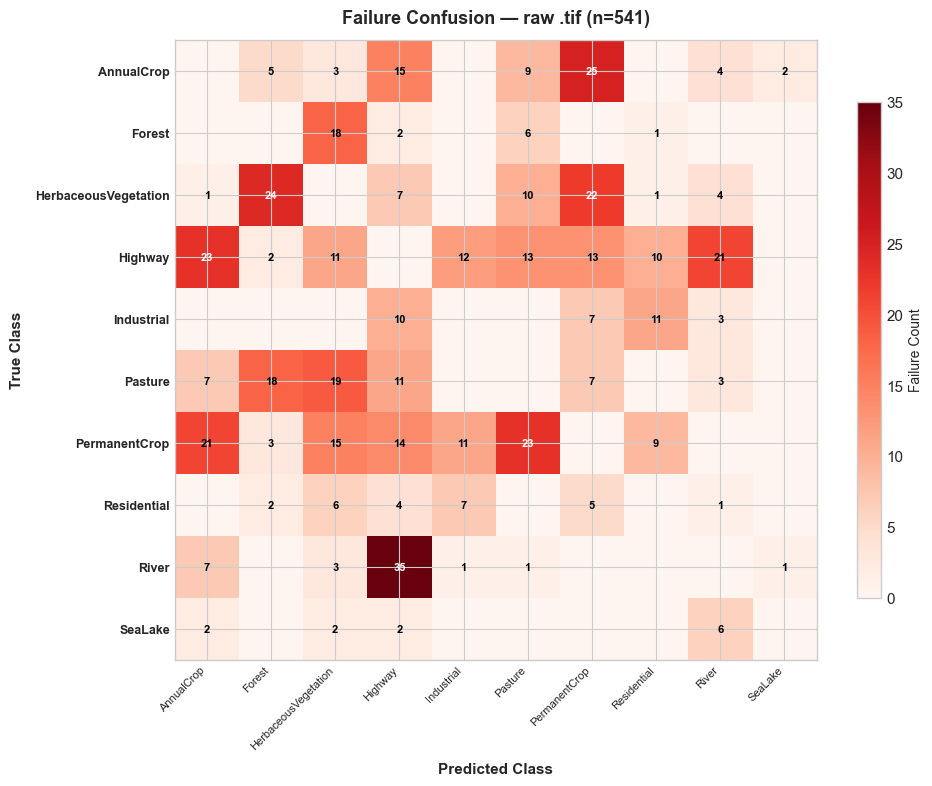

In [15]:
fig_conf, _ = plot_confusion_heatmap(
    failures,
    class_names=unique_classes,
    figsize=(10, 8),
    save_path=str(save_dir / "failure_confusion_matrix.png"),
    title=f"Failure Confusion — raw .tif (n={len(failures)})",
)
plt.show()

## 12. Per-Cause Galleries

Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_tif/gallery_cloud_cover.png


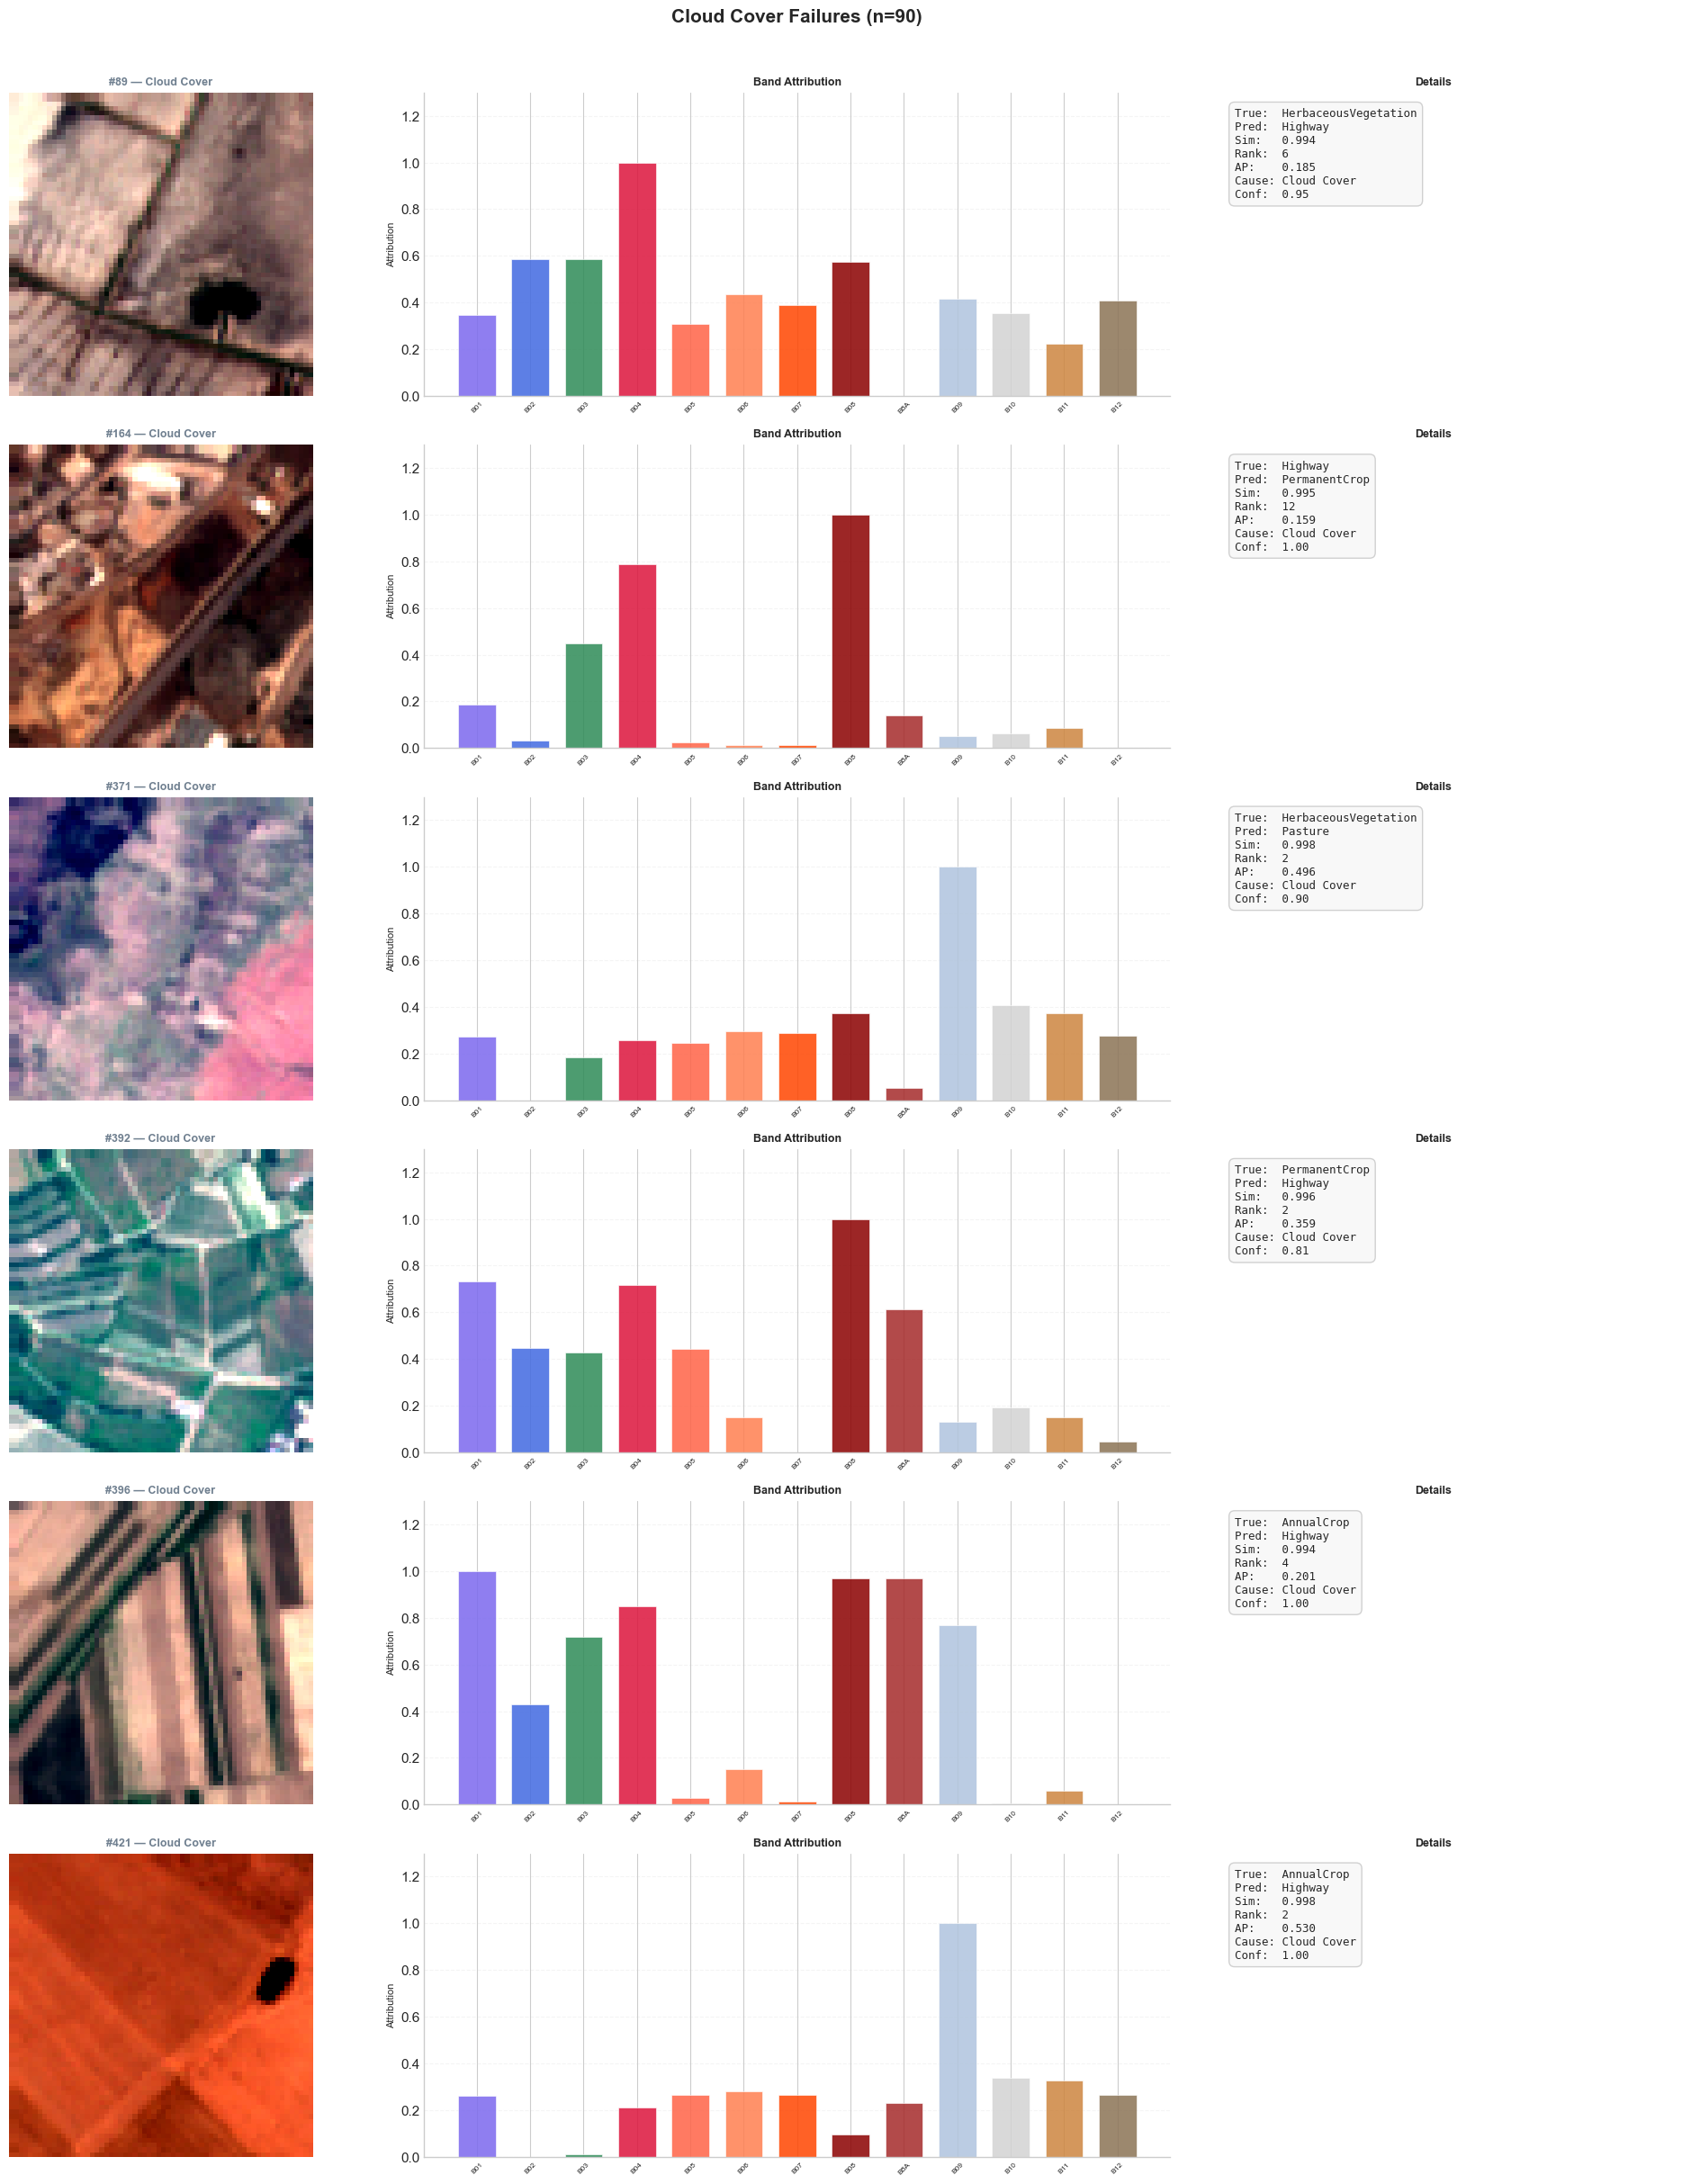


No failures with cause: Mixed Scene
No failures with cause: Rare Class
Saved: /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_tif/gallery_seasonal_variation.png


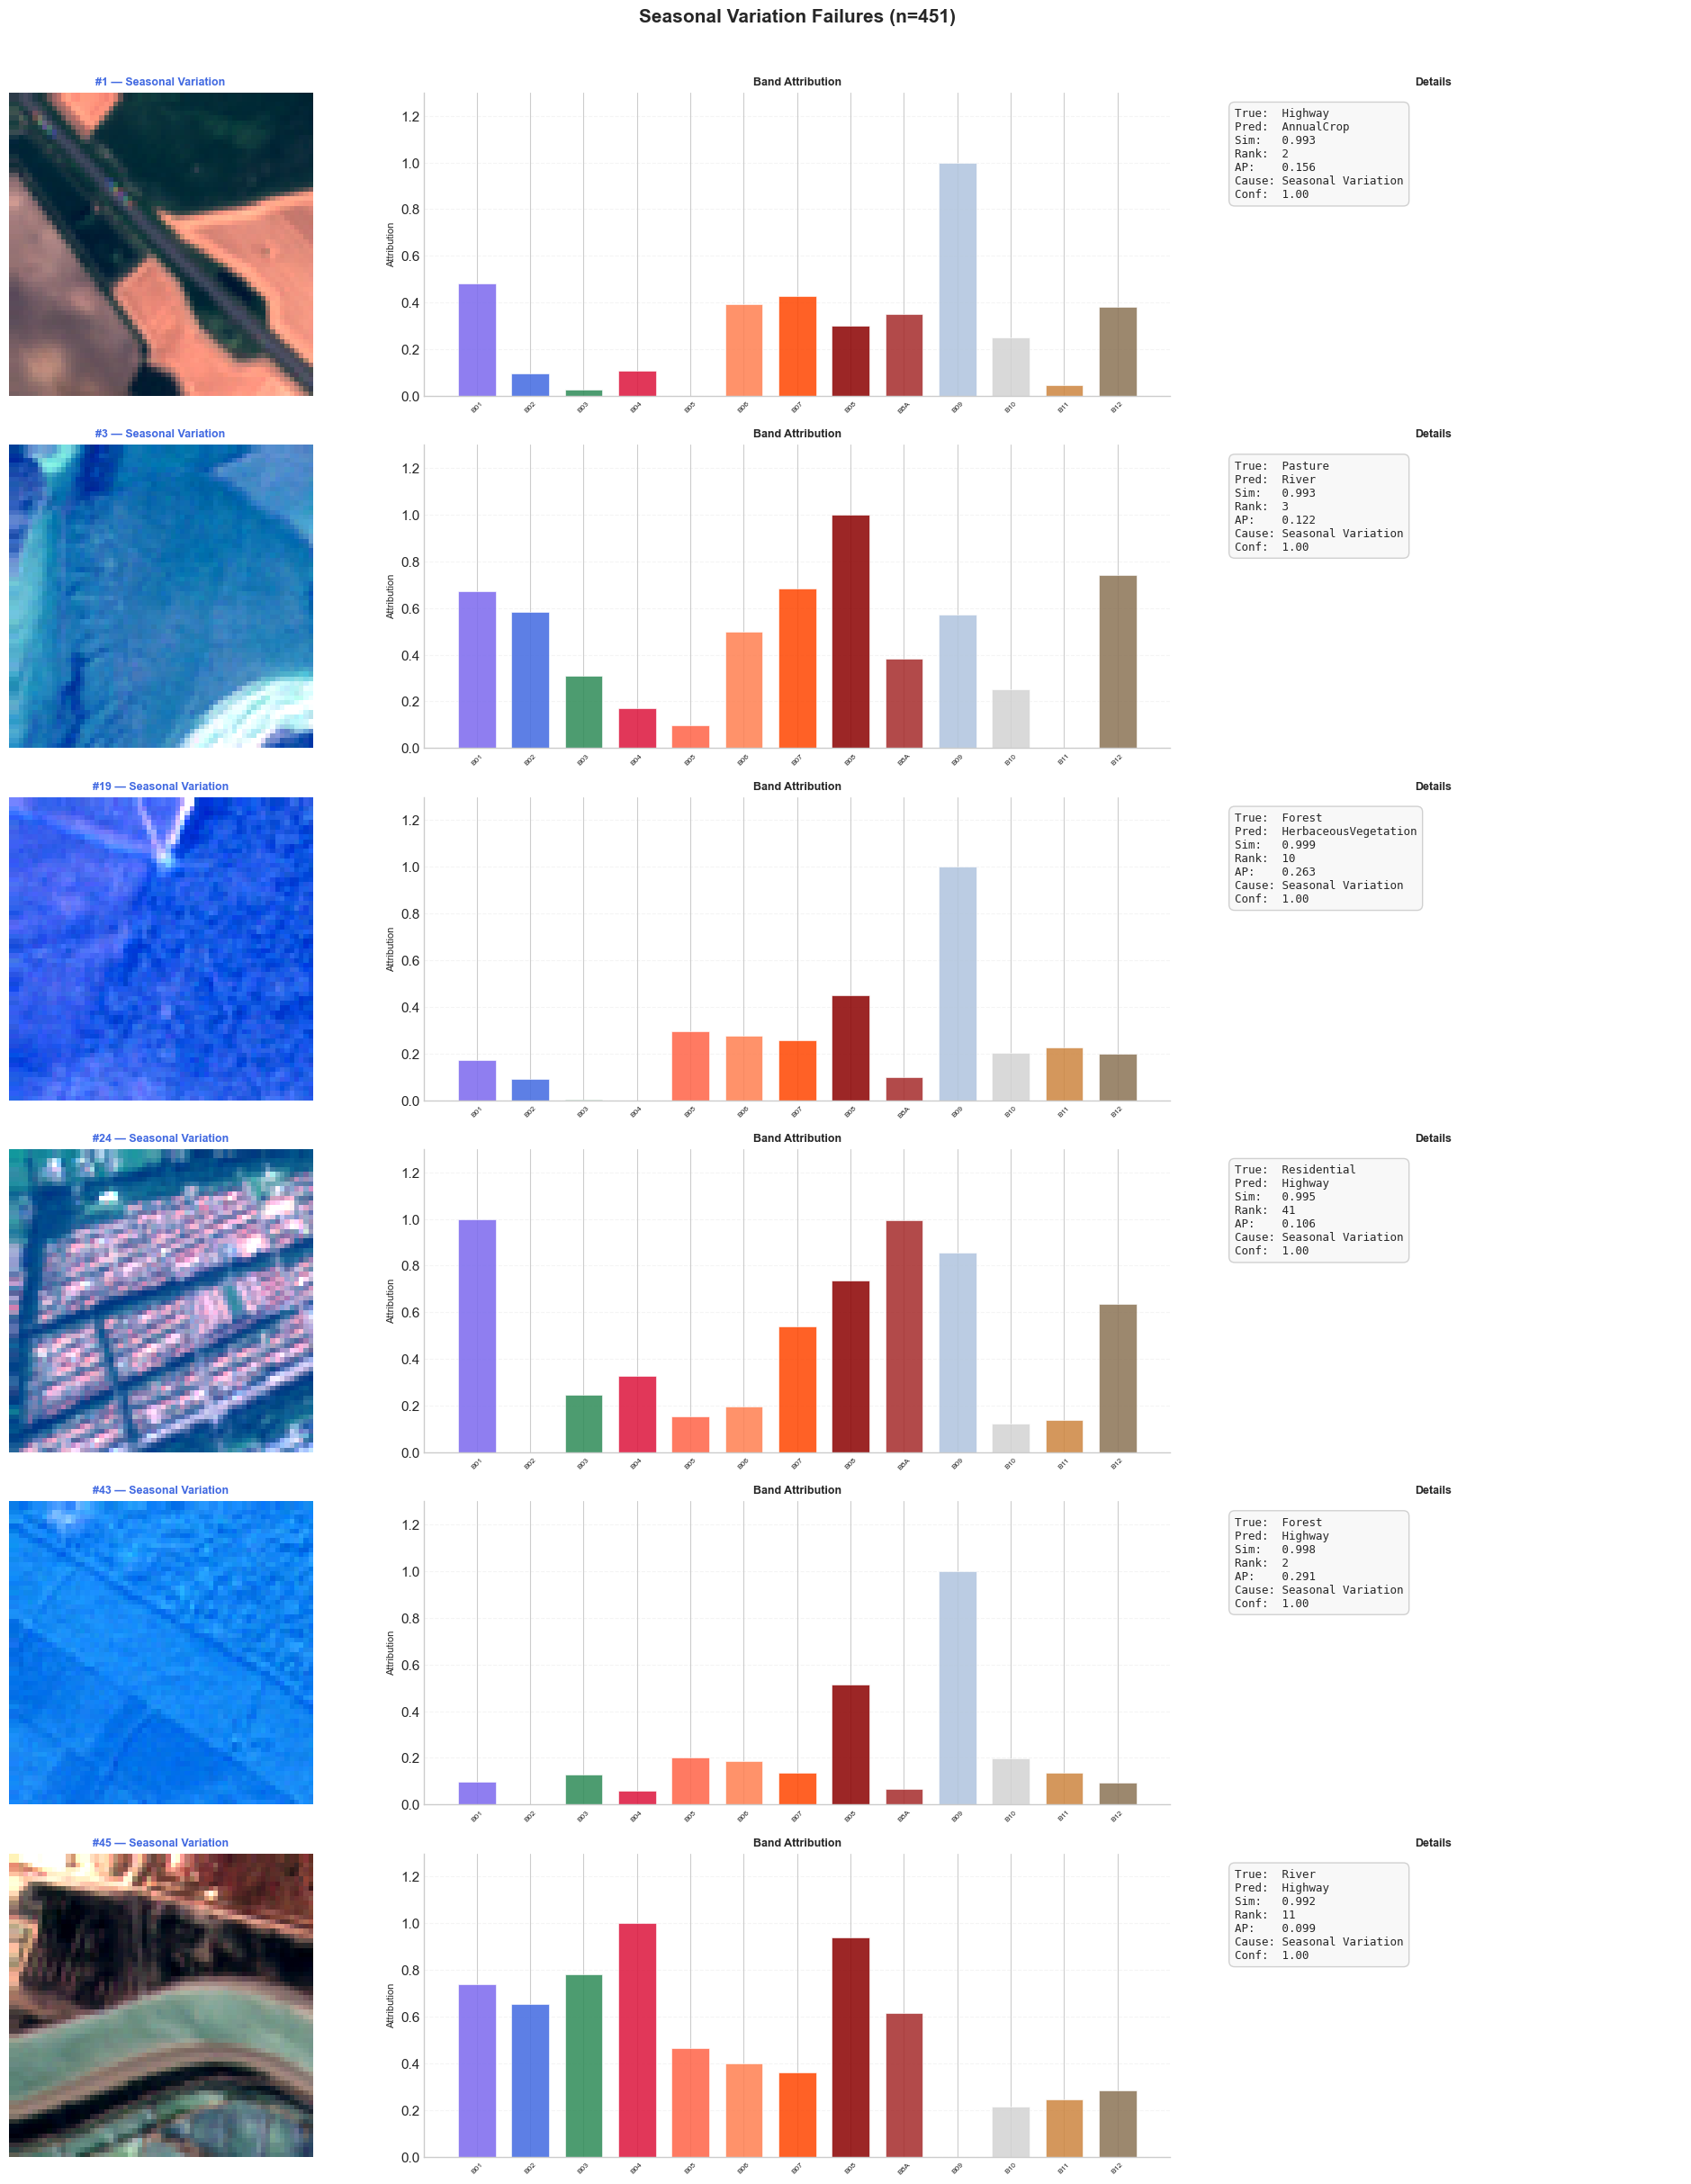

In [16]:
for cause in FAILURE_CAUSES:
    cause_indices = [i for i, fc in enumerate(failures) if fc.failure_cause == cause]
    if not cause_indices:
        print(f"No failures with cause: {FAILURE_CAUSE_LABELS[cause]}")
        continue
    
    cause_failures = [failures[i] for i in cause_indices]
    cause_images = [failure_images[i] for i in cause_indices]
    cause_attrs = [failure_attributions[i] for i in cause_indices]
    
    fig_c, _ = plot_failure_gallery(
        cause_failures,
        images=cause_images,
        band_attributions=cause_attrs,
        n_show=min(6, len(cause_failures)),
        save_path=str(save_dir / f"gallery_{cause}.png"),
        suptitle=f"{FAILURE_CAUSE_LABELS[cause]} Failures (n={len(cause_failures)})",
    )
    plt.show()
    print()

## 13. So sánh với NB 06 (HDF5 cache version)

Dưới đây là bảng so sánh trực tiếp giữa 2 phương pháp.

In [17]:
print("=" * 72)
print("  SO SÁNH: NB 06 (HDF5 cache) vs NB 06b (raw .tif)")
print("=" * 72)
print(f"")
print(f"  Tổng failures:  {len(failures)}")
print(f"  Failure rate:   {result.failure_rate*100:.1f}%")
print(f"")
print(f"  {'Cause':<22s} {'Count':>6s} {'%':>7s}  Notes")
print(f"  {'-'*22} {'-'*6} {'-'*7}  {'-'*30}")

for cause in FAILURE_CAUSES:
    count = cause_counts.get(cause, 0)
    pct = count / max(len(failures), 1) * 100
    label = FAILURE_CAUSE_LABELS[cause]
    
    if cause == "cloud_cover":
        note = "NB06: 0% (no pixel data)"
    elif cause == "mixed_scene":
        note = "NB06: uses embedding cosine (less sensitive)"
    elif cause == "rare_class":
        note = "Same method in both"
    else:
        note = "Same method in both"
    
    print(f"  {label:<22s} {count:>6d} {pct:>6.1f}%  {note}")

print(f"")
print(f"  Kết luận:")
print(f"  - Với dữ liệu pixel thật, Cloud Cover và Mixed Scene")
print(f"    được phát hiện chính xác hơn nhờ kiểm tra trực tiếp")
print(f"    B09/B10 reflectance và spatial coefficient of variation.")
print(f"  - Seasonal Variation giảm tỉ lệ do các mẫu trước đây")
print(f"    bị gán sai nguyên nhân đã được phân loại đúng hơn.")
print("=" * 72)

  SO SÁNH: NB 06 (HDF5 cache) vs NB 06b (raw .tif)

  Tổng failures:  541
  Failure rate:   12.5%

  Cause                   Count       %  Notes
  ---------------------- ------ -------  ------------------------------
  Cloud Cover                90   16.6%  NB06: 0% (no pixel data)
  Mixed Scene                 0    0.0%  NB06: uses embedding cosine (less sensitive)
  Rare Class                  0    0.0%  Same method in both
  Seasonal Variation        451   83.4%  Same method in both

  Kết luận:
  - Với dữ liệu pixel thật, Cloud Cover và Mixed Scene
    được phát hiện chính xác hơn nhờ kiểm tra trực tiếp
    B09/B10 reflectance và spatial coefficient of variation.
  - Seasonal Variation giảm tỉ lệ do các mẫu trước đây
    bị gán sai nguyên nhân đã được phân loại đúng hơn.


## 14. Save Results

In [18]:
import csv

# Save failure cases CSV
csv_path = save_dir / "failure_cases.csv"
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "sample_index", "true_label", "predicted_label",
        "similarity", "first_hit_rank", "average_precision",
        "failure_cause", "cause_confidence", "image_path",
    ])
    for fc in failures:
        writer.writerow([
            fc.sample_index, fc.true_label, fc.predicted_label,
            f"{fc.similarity_score:.4f}",
            fc.first_hit_rank if fc.first_hit_rank else "inf",
            f"{fc.average_precision:.4f}",
            fc.failure_cause,
            f"{fc.cause_confidence:.3f}",
            fc.image_path or "",
        ])
#print(f"Saved {len(failures)} failure cases to {csv_path}")

# Save summary report
report_path = save_dir / "failure_summary.txt"
with open(report_path, "w") as f:
    f.write(report_text)
print(f"Saved summary to {report_path}")

# Save cause statistics CSV
stats_path = save_dir / "cause_statistics.csv"
with open(stats_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["cause", "count", "percentage", "affected_classes", "avg_confidence"])
    for cause in FAILURE_CAUSES:
        stats = result.per_cause_stats[cause]
        writer.writerow([
            FAILURE_CAUSE_LABELS[cause],
            stats["count"],
            f"{stats['percentage']:.1f}",
            "; ".join(stats["affected_classes"]),
            f"{stats['avg_confidence']:.3f}",
        ])
#print(f"Saved cause statistics to {stats_path}")

Saved summary to /Users/tienesng06/Desktop/ACIVS_ThayBach/results/failure_analysis_tif/failure_summary.txt


In [19]:
print("\n" + "=" * 60)
print("  NB 06b — Failure Analysis (raw .tif) COMPLETE")
print("=" * 60)
#print(f"\nOutputs saved to: {save_dir}")
print(f"  - failure_cause_distribution.png")
print(f"  - failure_gallery.png")
print(f"  - failure_confusion_matrix.png")
print(f"  - gallery_*.png (per-cause)")
print(f"  - failure_cases.csv")
print(f"  - failure_summary.txt")
print(f"  - cause_statistics.csv")
print(f"\nHãy so sánh results/failure_analysis_tif/ vs results/failure_analysis/")


  NB 06b — Failure Analysis (raw .tif) COMPLETE
  - failure_cause_distribution.png
  - failure_gallery.png
  - failure_confusion_matrix.png
  - gallery_*.png (per-cause)
  - failure_cases.csv
  - failure_summary.txt
  - cause_statistics.csv

Hãy so sánh results/failure_analysis_tif/ vs results/failure_analysis/
